# Machine Learning Method: Seasonal and Trend Decomposition using Loess (STL)


Einführung in die Methode Seasonal and Trend Decomposition using Loess.

In [4]:
import sys
print(sys.version)

3.8.8 (default, Apr 13 2021, 12:59:45) 
[Clang 10.0.0 ]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

1. Dummy Zeitreihe

In [6]:
np.random.seed(42)
dates = pd.date_range(start="2021-02-01",periods=60,freq="M")

Komponenten Trend, Saisonalität, Noise

In [7]:
trend = np.linspace(10, 50, 60)
seasonality = 10 * np.sin(2 * np.pi * dates.month / 12)
noise = np.random.normal(0, 2, 60)
values = trend + seasonality + noise

In [8]:
# Combine into a Pandas Series with a datetime index
data = pd.Series(values, index=dates)

In [9]:
# 2. Apply STL Decomposition
# 'period' is the number of observations per cycle (12 for monthly data)
stl = STL(data, period=12, robust=True)
res = stl.fit()

In [10]:
# 3. Extract the components
trend_component = res.trend
seasonal_component = res.seasonal
residual_component = res.resid

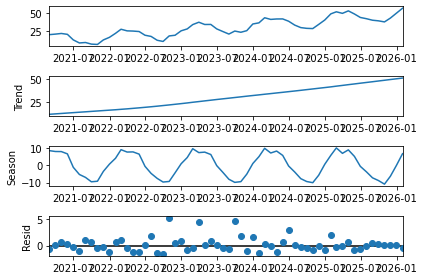

In [11]:
# 4. Plot the results
fig = res.plot()
plt.tight_layout()
plt.show()

### Key Parameters to Customize
When working with your own data, you will likely need to tweak the STL parameters to get the best fit:
 * **period (int):** The seasonality length. For example:
   * Monthly data: 12
   * Daily data with weekly seasonality: 7
   * Quarterly data: 4
 * **robust (bool):** Setting this to True allows the LOESS weights to ignore large outliers, preventing them from distorting the trend and seasonal components.
 * **seasonal (int):** The smoothing parameter for the seasonal component (must be an odd integer). A smaller value allows the seasonal pattern to change rapidly over time, while a larger value forces it to be more stable.
 * **trend (int):** The smoothing parameter for the trend component (must be an odd integer). Larger values result in a smoother, more linear trend.
### Accessing the Data Directly
If you want to use the decomposed data for further analysis (like forecasting or anomaly detection), you can easily convert them back into a Pandas DataFrame:




In [14]:
df_components = pd.DataFrame({
    'Observed': data,
    'Trend': res.trend,
    'Seasonal': res.seasonal,
    'Residual': res.resid
})

In [15]:
print(df_components.head())

             Observed      Trend  Seasonal  Residual
2021-02-28  19.653682  11.913897  8.414204 -0.674419
2021-03-31  20.401437  12.357780  7.927116  0.116541
2021-04-30  21.311563  12.801300  7.881050  0.629213
2021-05-31  20.079958  13.244898  6.559409  0.275651
2021-06-30  12.243558  13.688695 -1.178103 -0.267034
